# LeetCode #67: Add Binary

https://leetcode.com/problems/add-binary/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Convert to int (overflow risk)** | $O(n)$ | $O(1)$ |
| **Right-to-Left with Carry** ★ | $O(\max(m,n))$ | $O(\max(m,n))$ |

---

## Understanding the Methods

### Why Not Convert to Integer?
For binary strings of length up to $10^4$, the value far exceeds int64 range. Direct integer conversion fails.

### Optimal: Right-to-Left with Carry ★
Simulate grade-school binary addition:
1. Maintain two pointers `i` (end of a) and `j` (end of b) and a `carry`.
2. Each iteration: `sum = carry + (a[i] if i>=0 else 0) + (b[j] if j>=0 else 0)`.
3. Append `sum % 2` to result; `carry = sum / 2`. Decrement i and j.
4. Continue while `i >= 0 OR j >= 0 OR carry > 0`.
5. The result is built in reverse; reverse at the end (or use StringBuilder.Insert(0,...)).

**Constraints:**
* $1 \leq$ a.length, b.length $\leq 10^4$
* `a` and `b` consist only of `'0'` or `'1'` characters
* Each string does not contain leading zeros except for the zero itself

## Solutions

### C#

In [ ]:
public class Solution {
    public string AddBinary(string a, string b) {
        var result = new System.Text.StringBuilder();
        int i = a.Length - 1, j = b.Length - 1, carry = 0;
        while (i >= 0 || j >= 0 || carry > 0) {
            int sum = carry;
            if (i >= 0) sum += a[i--] - '0';
            if (j >= 0) sum += b[j--] - '0';
            result.Insert(0, sum % 2); // prepend bit
            carry = sum / 2;
        }
        return result.Length == 0 ? "0" : result.ToString();
    }
}

### Python

In [ ]:
class Solution:
    def addBinary(self, a: str, b: str) -> str:
        result = []
        i, j, carry = len(a) - 1, len(b) - 1, 0
        while i >= 0 or j >= 0 or carry:
            s = carry
            if i >= 0:
                s += int(a[i]); i -= 1
            if j >= 0:
                s += int(b[j]); j -= 1
            result.append(str(s % 2))
            carry = s // 2
        return ''.join(reversed(result)) or '0'

### Go

In [ ]:
package main

func addBinary(a string, b string) string {
	result := []byte{}
	i, j, carry := len(a)-1, len(b)-1, 0
	for i >= 0 || j >= 0 || carry > 0 {
		sum := carry
		if i >= 0 {
			sum += int(a[i] - '0')
			i--
		}
		if j >= 0 {
			sum += int(b[j] - '0')
			j--
		}
		result = append(result, byte('0'+sum%2))
		carry = sum / 2
	}
	// reverse
	for l, r := 0, len(result)-1; l < r; l, r = l+1, r-1 {
		result[l], result[r] = result[r], result[l]
	}
	return string(result)
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn add_binary(a: String, b: String) -> String {
        let a = a.as_bytes();
        let b = b.as_bytes();
        let (mut i, mut j) = (a.len() as i32 - 1, b.len() as i32 - 1);
        let mut carry = 0u8;
        let mut result = Vec::new();
        while i >= 0 || j >= 0 || carry > 0 {
            let mut sum = carry;
            if i >= 0 { sum += a[i as usize] - b'0'; i -= 1; }
            if j >= 0 { sum += b[j as usize] - b'0'; j -= 1; }
            result.push(b'0' + sum % 2);
            carry = sum / 2;
        }
        result.reverse();
        String::from_utf8(result).unwrap_or(String::from("0"))
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `a = "11", b = "1"`

Walk through: Process right-to-left. Position 0: 1+1+0=2 → bit=0, carry=1. Position 1: 1+0+1=2 → bit=0, carry=1. Position 2: 0+0+1=1 → bit=1, carry=0. Reverse → "100". (Decimal: 3+1=4.)

**Why tricky:** Simple case with a carry that propagates two positions. The result is one bit longer than the longer input. Interviewers verify basic carry mechanics.

### 2. Slightly Complex — Equal Length with Multiple Carries
**Input:** `a = "1010", b = "1011"`

Walk through: Pos 0: 0+1=1→bit=1,carry=0. Pos 1: 1+1=2→bit=0,carry=1. Pos 2: 0+0+1=1→bit=1,carry=0. Pos 3: 1+1=2→bit=0,carry=1. Extra: carry=1→bit=1. Result: "10101". (Decimal: 10+11=21.)

**Why tricky:** Carry appears, disappears, and reappears throughout the computation. Tests that carry logic handles the start/stop pattern correctly, not just a single ripple.

### 3. Edge Case: Time Factor — Maximum Length with Full Carry Ripple
**Input:** `a = "111...1"` (10,000 ones), `b = "1"`

Walk through: Position 0: 1+1=2→bit=0,carry=1. Positions 1-9999: 1+0+1=2→bit=0,carry=1 (ripple continues through all 10,000 positions). Position 10000: 0+0+1=1→bit=1. Result: "1" followed by 10,000 zeros. Total iterations = 10,001.

**Why tricky:** Worst case for time: carry propagates through every position. This is why converting to integer fails: $2^{10{,}000} \gg 2^{63}$ (far exceeds int64 range). String-based addition with $O(\max(m,n))$ iterations is mandatory.

### 4. Edge Case: Space Factor — Vastly Different Lengths
**Input:** `a = "1"` (1 char), `b = "10101...01"` (10,000 chars)

Walk through: After 1 iteration, the shorter string is exhausted. The remaining 9,999 iterations process b alone (treating missing a-digits as 0). Result length: up to 10,001 chars. Space = $O(\max(m,n))$ for the result StringBuilder.

**Why tricky:** When $m \ll n$, the loop must correctly treat missing digits as 0 (not crash with index-out-of-bounds). The result's space $O(\max(m,n))$ is unavoidable. Interviewers check boundary handling when one string runs out.

### 5. Almost-Impossible but Plausible — Both Zeros and Carry-Only Output
**Input A:** `a = "0", b = "0"` | **Input B:** `a = "1", b = "1"`

Walk through A: 0+0=0 → bit=0, carry=0. Result: "0". Must not return "" (empty) or "00". Walk through B: 1+1=2 → bit=0, carry=1. Then carry=1 → bit=1. Result: "10". The loop must continue while carry > 0.

**Why tricky:** Two minimal boundary cases: (1) "0"+"0" must output exactly "0" — not empty, not "00". (2) "1"+"1" relies on the `carry > 0` loop condition to produce the leading "1". Forgetting this condition is the #1 bug. Loop condition must be: `while (i >= 0 OR j >= 0 OR carry > 0)`.

---

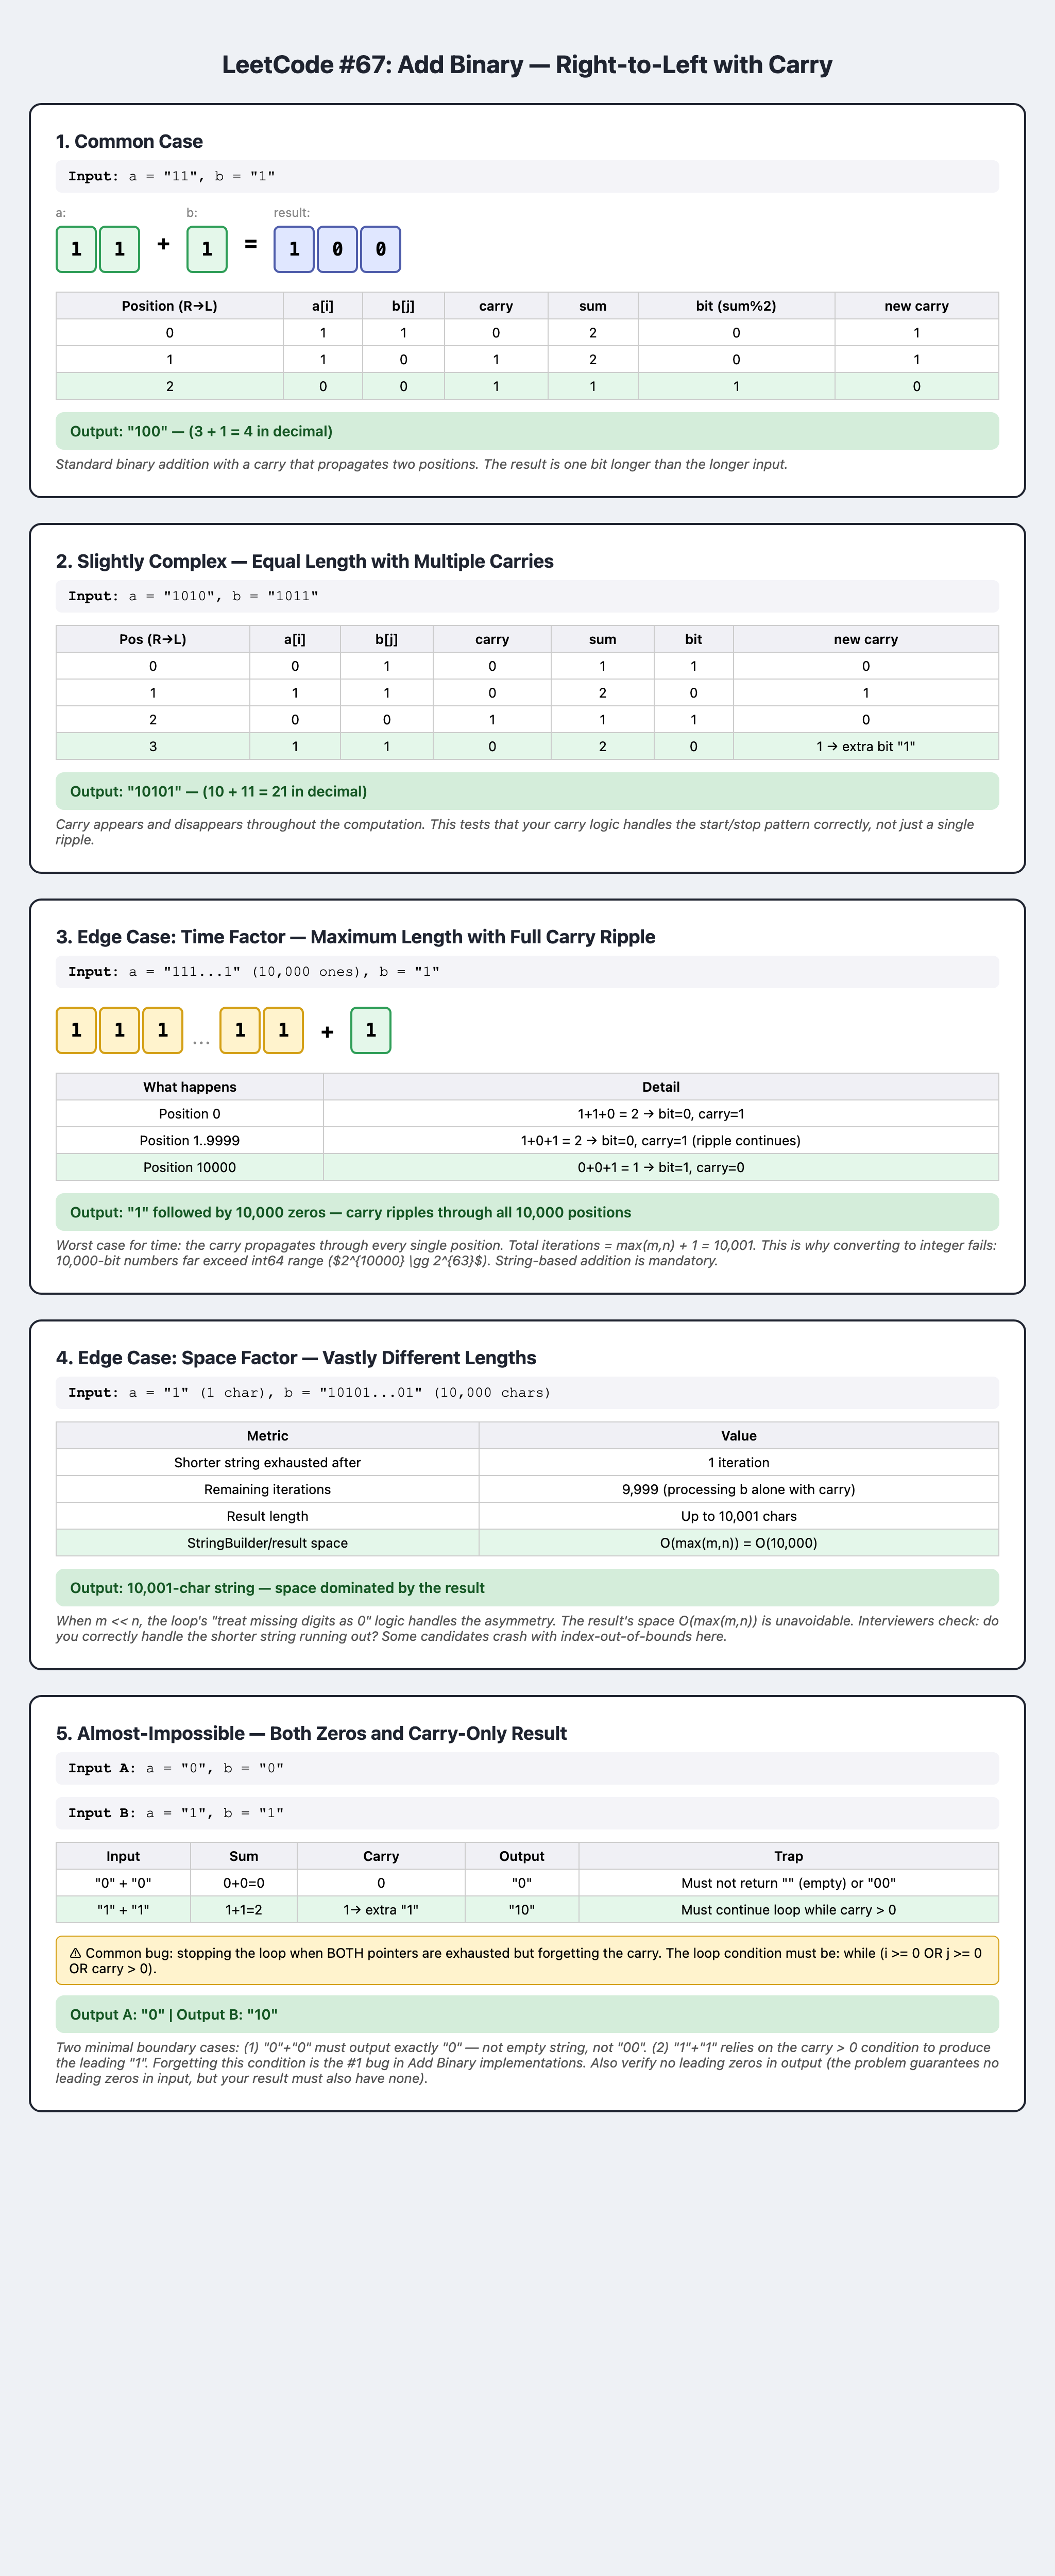